In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.decomposition import PCA
from PIL import Image
import yaml

import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import v2
import torchvision.transforms as transforms
from torchvision.models import vit_l_16, ViT_L_16_Weights
from torchvision.io import decode_image

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.base_cam import BaseCAM

from scripts.model import Custom_ResNet50, Custom_DenseNet121, ModelWrapper
from scripts.preprocessing import get_hilbert_index, hilbert_ravel, pipeline
import scripts.gradcam

# Get and View Grad-CAMs

This tool allows for easy viewing of the Grad-CAM image masks which highlight the regions of the image which the model finds the most important in its decision-making

#### Main Model Parameters

```
model_type: The model architecture parameter ("ResNet50" or "DenseNet121")
dim: The input image dimension parameter (224 or 384)
enhanced: Use models trained on enhanced images (True or False

row_idx: The image row index from the input .csv
```

#### Other Variables

```
save_combined_gradcam_fig: Save a combined plot containing all gradcam images
save_separate_gradcams: Save individual gradcam images (5x total)
```

In [2]:
### Use test data frame
df = pd.read_csv("data/test_df.csv")

print(f"Choose a row index from 0 to {len(df)}")

Choose a row index from 0 to 39371


In [31]:
row_idx = 10

In [32]:
### Extract the associated path
img_path = df.loc[row_idx, "source_file_path"]

In [33]:
### Activate these to save grad-CAM displays
save_combined_gradcam_fig = True
save_separate_gradcams = True

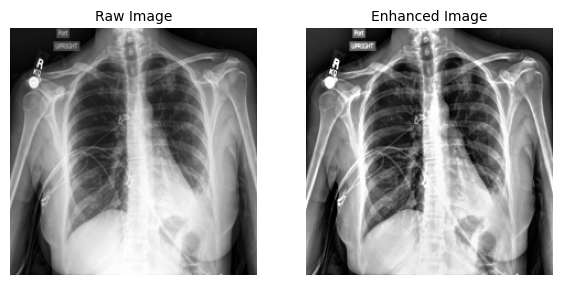

In [34]:
# View the selected image
fig,ax = plt.subplots(1,2, figsize=(7,4))

imgs, img_enhanceds = pipeline(img_path, [224])
ax[0].imshow(imgs[0], cmap="gray")
ax[0].axis("off")
ax[0].set_title("Raw Image", fontsize=10)
#
ax[1].imshow(img_enhanceds[0], cmap="gray")
ax[1].axis("off")
ax[1].set_title("Enhanced Image", fontsize=10)

plt.show()

#### Viewing grad-CAMs of a custom model/csv

**csv_path**: The filepath to the .csv containing the predictions. This is either manually specified or automatically set to:
* ```f"results/{model_type}_BASE{dim}_ENHANCED_test_withPredictionsAndConfidences.csv"``` for enhanced images or
* ```f"results/{model_type}_BASE{dim}_test_withPredictionsAndConfidences.csv"``` for raw images

**model_path**: The filepath to the .pth containing the trained model. This is either manually specified or automatically set to:
* ```f"models/{model_type}_BASE{dim}_ENHANCED.pth"``` for enhanced images or
* ```f"models/{model_type}_BASE{dim}.pth"``` for raw images

In [35]:
# VIEW CUSTOM RESULTS/MODEL
view_gradcams_for_custom_configuration = False

if view_gradcams_for_custom_configuration:
    print("Displaying custom results")
    
    # Enter parameters - ensure that the model type, dimension, and enhanced parameters match the csv/model paths
    model_type="DenseNet121",
    dim=224,
    enhanced=False,
    row_idx=row_idx,
    #
    csv_path = "results/DenseNet121_BASE224_test_withPredictionsAndConfidences.csv", # example: "results/DenseNet121_BASE224_test_withPredictionsAndConfidences.csv"
    model_path = "models/DenseNet121_BASE224.pth", # example: "models/ResNet50_BASE224.pth"
    
    ##### Wrap into a kwargs dict and get images
    wrapper_kwargs = dict(
        model_type=model_type, dim=dim, enhanced=enhanced, row_idx=row_idx, csv_path=csv_path, model_path=model_path
    )
    
    #####
    gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(**wrapper_kwargs)
    fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, save_combined_gradcam_fig=save_combined_gradcam_fig, **overlay_kwargs)
    #
    if save_separate_gradcams:
        scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs)

## View Grad-CAM for the trained models

In [36]:
### Load wrapper_kwargs
with open("config/wrapper_kwargs.yaml", "r") as params:
    wrapper_kwargs = yaml.safe_load(params)

#### RAW IMAGES, RESNET50, 224x224

Combined figure saved to gradcam/ALL_RAW_ResNet50_BASE224_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_RAW_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_RAW_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_RAW_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_RAW_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_RAW_gradcam_condition_4_Pleural Effusion.png


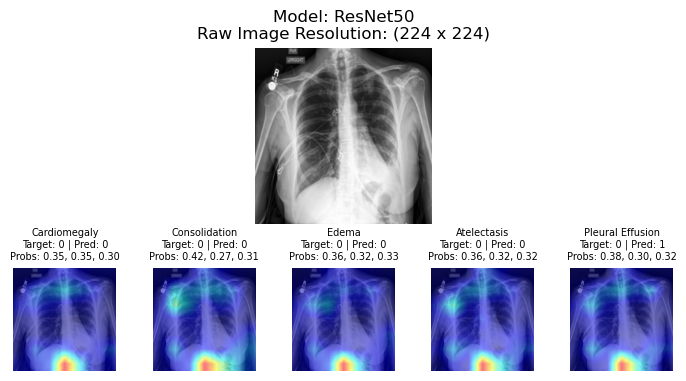

In [37]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs0"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs0"])

#### ENHANCED IMAGES, RESNET50, 224x224

Combined figure saved to gradcam/ALL_ENHANCED_ResNet50_BASE224_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_ENHANCED_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_ENHANCED_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_ENHANCED_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_ENHANCED_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base224_ENHANCED_gradcam_condition_4_Pleural Effusion.png


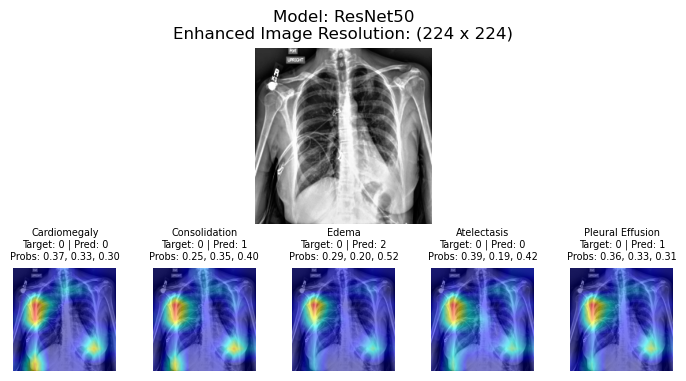

In [38]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs1"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs1"])

#### RAW IMAGES, RESNET50, 384x384

Combined figure saved to gradcam/ALL_RAW_ResNet50_BASE384_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_RAW_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_RAW_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_RAW_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_RAW_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_RAW_gradcam_condition_4_Pleural Effusion.png


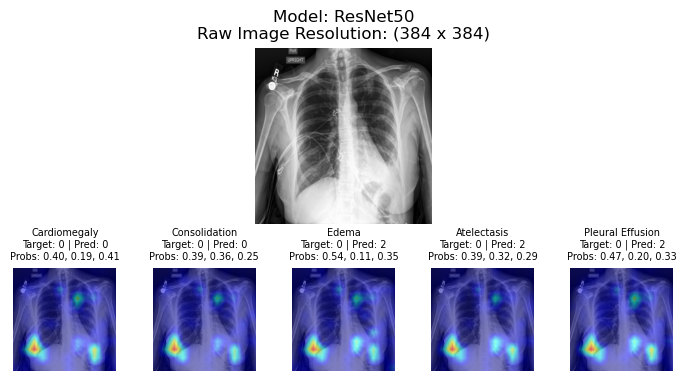

In [39]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs2"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs2"])

#### ENHANCED IMAGES, RESNET50, 384x384

Combined figure saved to gradcam/ALL_ENHANCED_ResNet50_BASE384_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_ENHANCED_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_ENHANCED_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_ENHANCED_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_ENHANCED_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_ResNet50_base384_ENHANCED_gradcam_condition_4_Pleural Effusion.png


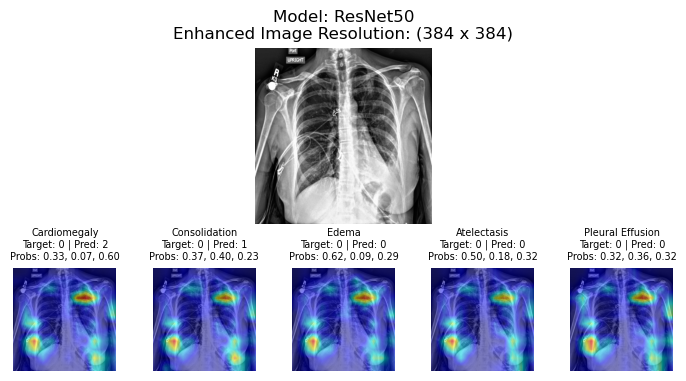

In [40]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs3"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs3"])

#### RAW IMAGES, DENSENET, 224x224

Combined figure saved to gradcam/ALL_RAW_DenseNet121_BASE224_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_RAW_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_RAW_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_RAW_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_RAW_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_RAW_gradcam_condition_4_Pleural Effusion.png


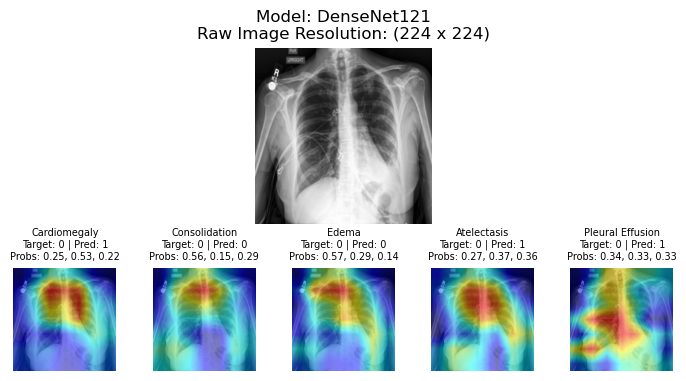

In [41]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs4"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs4"])

#### ENHANCED IMAGES, DENSENET, 224x224

Combined figure saved to gradcam/ALL_ENHANCED_DenseNet121_BASE224_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_ENHANCED_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_ENHANCED_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_ENHANCED_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_ENHANCED_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base224_ENHANCED_gradcam_condition_4_Pleural Effusion.png


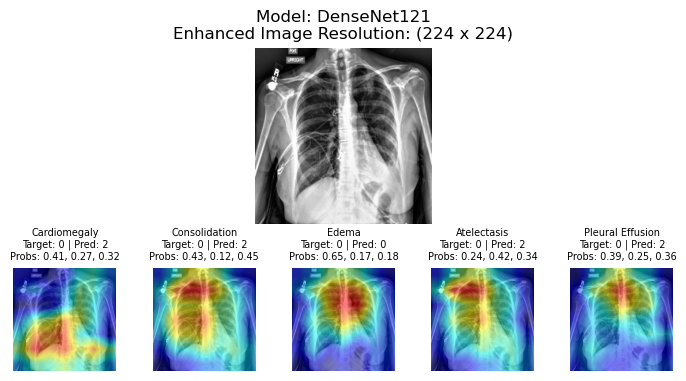

In [42]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs5"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs5"])

#### RAW IMAGES, DENSENET, 384x384

Combined figure saved to gradcam/ALL_RAW_DenseNet121_BASE384_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_RAW_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_RAW_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_RAW_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_RAW_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_RAW_gradcam_condition_4_Pleural Effusion.png


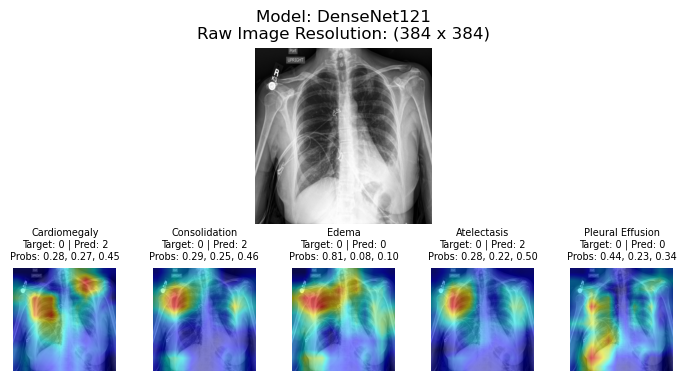

In [43]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs6"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs6"])

#### ENHANCED IMAGES, DENSENET, 384x384

Combined figure saved to gradcam/ALL_ENHANCED_DenseNet121_BASE384_allGradcams.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_ENHANCED_gradcam_condition_0_Cardiomegaly.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_ENHANCED_gradcam_condition_1_Consolidation.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_ENHANCED_gradcam_condition_2_Edema.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_ENHANCED_gradcam_condition_3_Atelectasis.png
Individual gradcam images saved to results/gradcam/patient43021_DenseNet121_base384_ENHANCED_gradcam_condition_4_Pleural Effusion.png


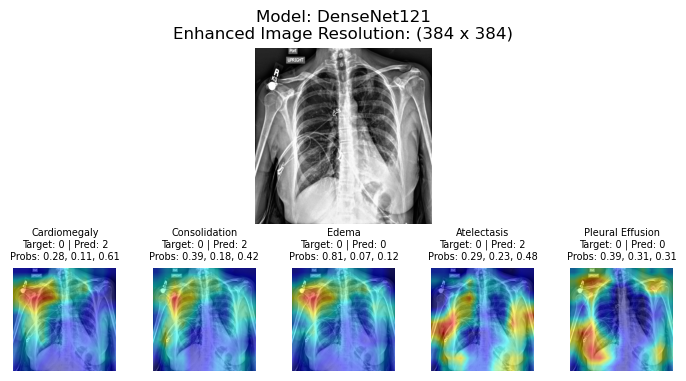

In [44]:
gradcam_masks, gradcam_images, patientID, overlay_kwargs = scripts.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                     **wrapper_kwargs["wrapper_kwargs7"])
fig, axes = scripts.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           **overlay_kwargs)
#
if save_separate_gradcams:
    scripts.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, patientID=patientID, **wrapper_kwargs["wrapper_kwargs7"])